<a href="https://colab.research.google.com/github/Atharv-Chopade/Deep-Learning/blob/main/SVM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [91]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [92]:
from sklearn.datasets import load_wine

In [93]:
data = load_wine()
df = pd.DataFrame(data.data,columns = data.feature_names)
df['target'] = data.target

In [94]:
df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [95]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [96]:
X = df.drop('target' , axis = 1)
y = df['target']

In [97]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state = 42)

In [98]:
scaler = StandardScaler()

In [99]:
X_trainscaled = scaler.fit_transform(X_train)
X_testscaled = scaler.transform(X_test)

In [100]:
from sklearn.svm import SVC
model = SVC(kernel = 'rbf',C = 1,gamma = 'scale')

In [101]:
model.fit(X_trainscaled,y_train)

SVC(C=1)

In [102]:
y_pred = model.predict(X_testscaled)

In [103]:
from sklearn.metrics import classification_report,confusion_matrix,RocCurveDisplay,ConfusionMatrixDisplay

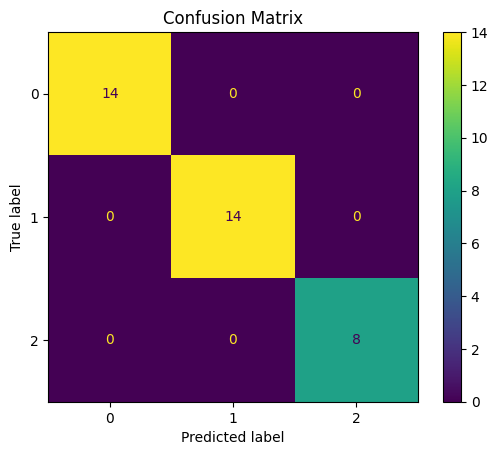

In [104]:
ConfusionMatrixDisplay.from_estimator(model,X_testscaled,y_test)
plt.title('Confusion Matrix')
plt.show()

In [105]:
print(classification_report(y_pred, y_test))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00         8

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



In [106]:
kernel = ['linear','poly','rbf','sigmoid']
c = [0.1,1,10,100]

In [107]:
acc = []

In [108]:
from sklearn.metrics import accuracy_score

In [109]:
for k in kernel:
  acctemp = []
  for i in c:
      mode = SVC(kernel = k, C=i,gamma = 'scale')
      mode.fit(X_trainscaled,y_train)
      y_pred = mode.predict(X_testscaled)
      acctemp.append(accuracy_score(y_pred,y_test))
  acc.append(acctemp)


In [110]:
print(acc)

[[0.9722222222222222, 0.9722222222222222, 0.9722222222222222, 0.9722222222222222], [0.6944444444444444, 0.9722222222222222, 0.9722222222222222, 0.9722222222222222], [1.0, 1.0, 1.0, 1.0], [1.0, 0.9722222222222222, 0.9722222222222222, 0.9444444444444444]]


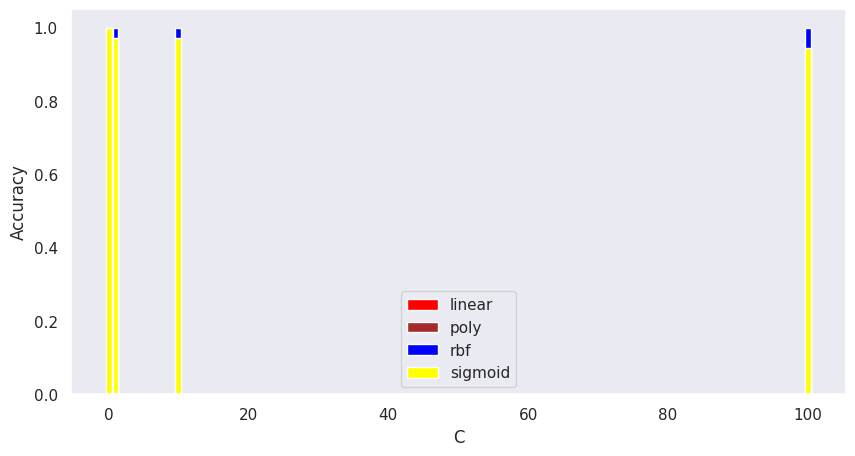

In [125]:
sns.set_theme(style = 'dark')
plt.figure(figsize = (10,5))
plt.bar(c,acc[0],label = kernel[0], color = 'red')
plt.bar(c,acc[1],label = kernel[1],color = 'brown')
plt.bar(c,acc[2],label = kernel[2],color = 'blue')
plt.bar(c,acc[3],label = kernel[3],color = 'yellow')
plt.xlabel('C')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [113]:
from sklearn.model_selection import cross_val_score

In [114]:
model = SVC(kernel = 'rbf',C = 1,gamma = 'scale')

In [118]:
model.fit(X_trainscaled , y_train)

SVC(C=1)

In [121]:
score = cross_val_score(
    model ,
    X_trainscaled ,
    y_train ,
    cv = 5 ,
    scoring = 'accuracy'
)

In [122]:
score

array([0.96551724, 0.96551724, 1.        , 0.96428571, 0.96428571])

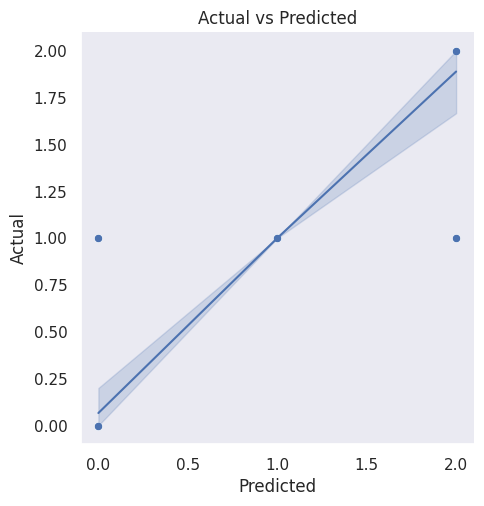

In [131]:
sns.relplot(x = y_pred , y = y_test)
sns.lineplot(x = y_pred , y = y_test)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Actual vs Predicted')
plt.show()